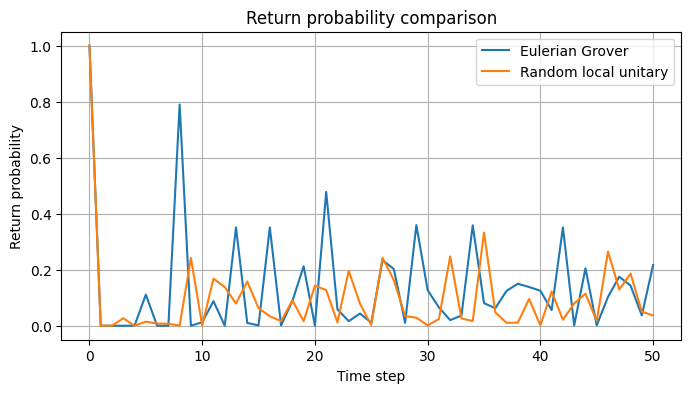

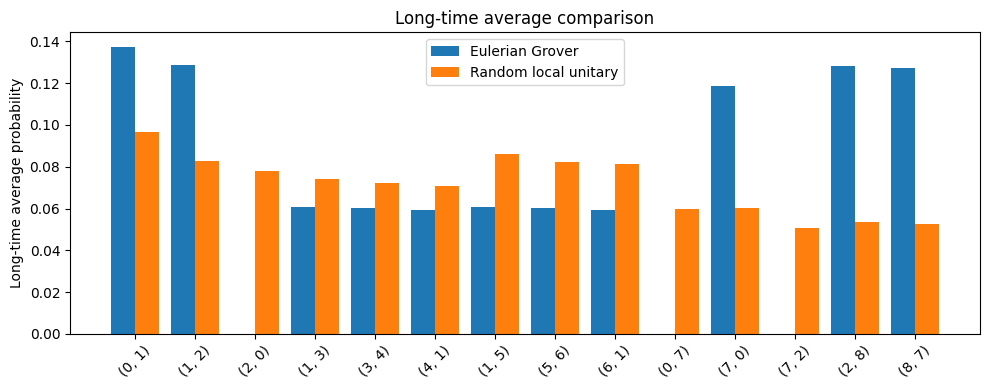

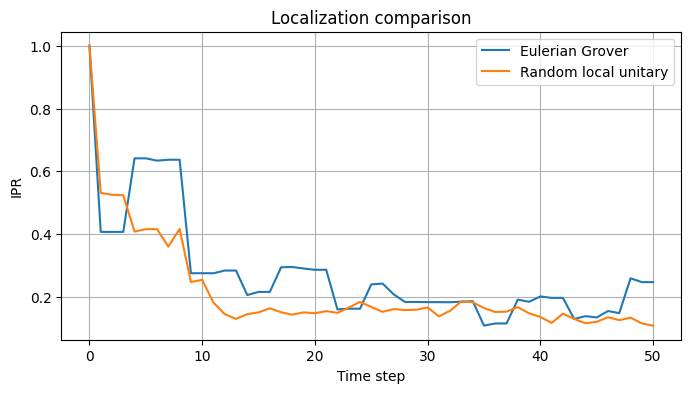

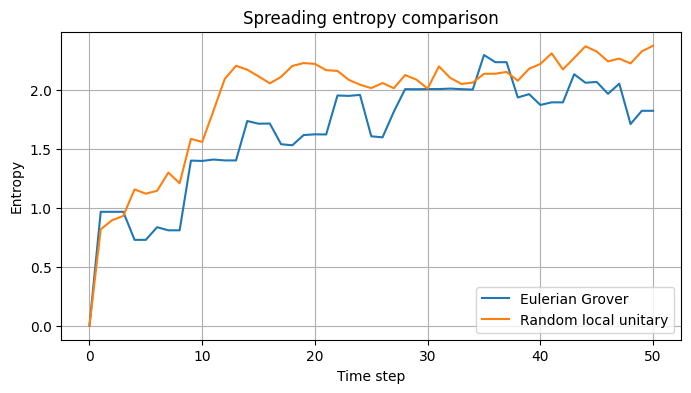

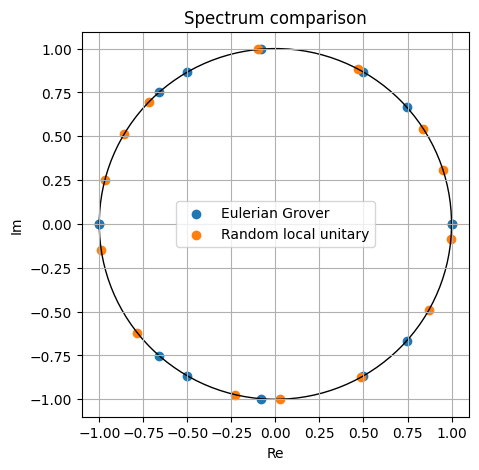

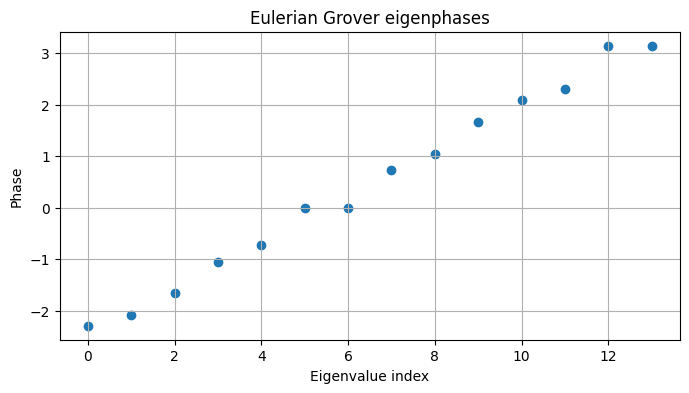

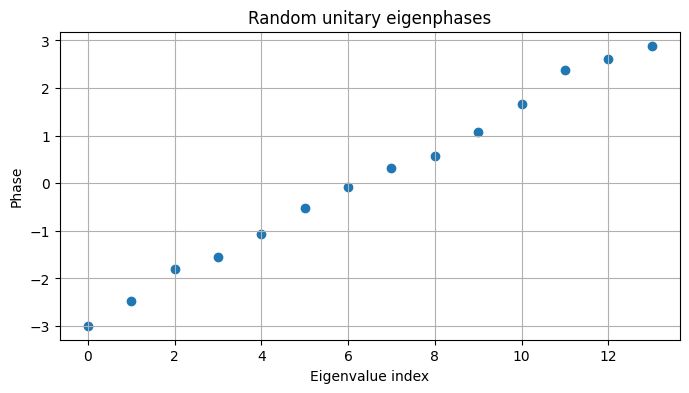

Grover degeneracies:
Phase -0.000000 has degeneracy 2
Phase 3.141593 has degeneracy 2
Random degeneracies:


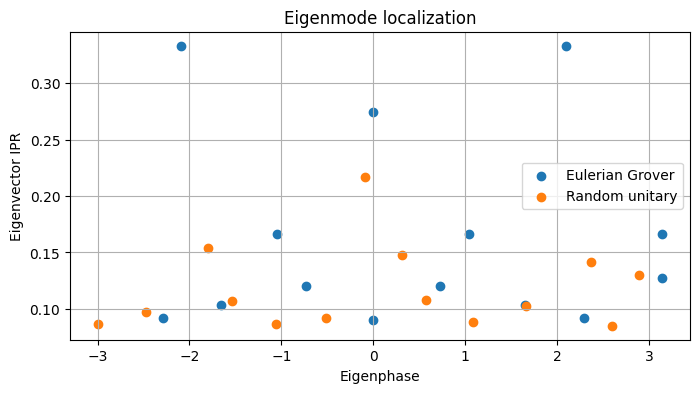

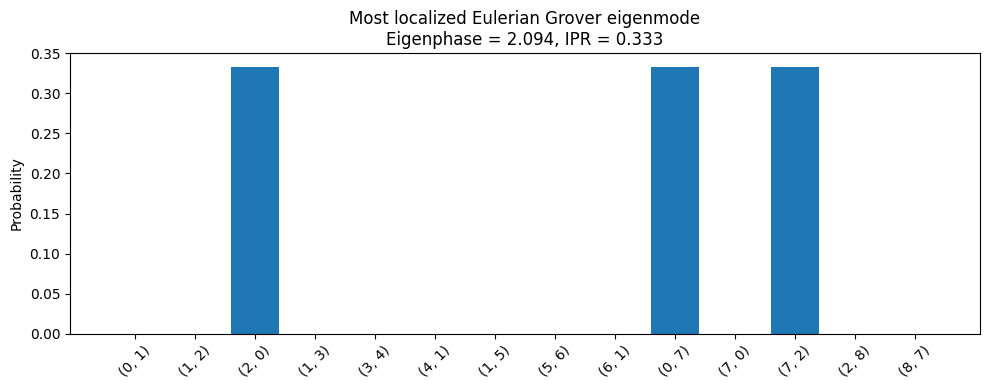

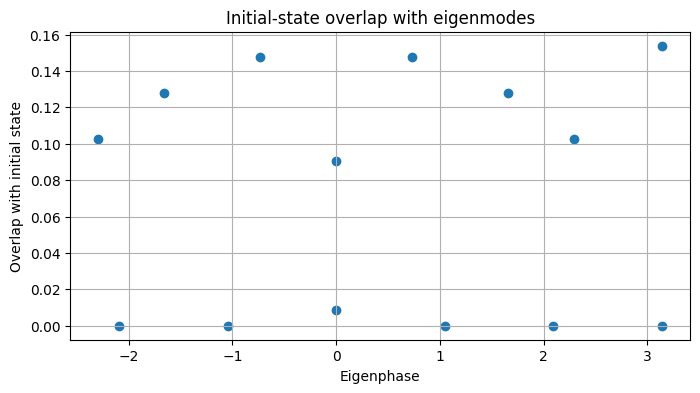

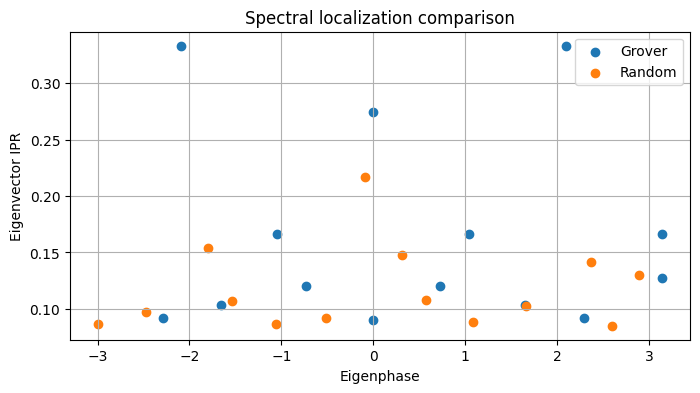

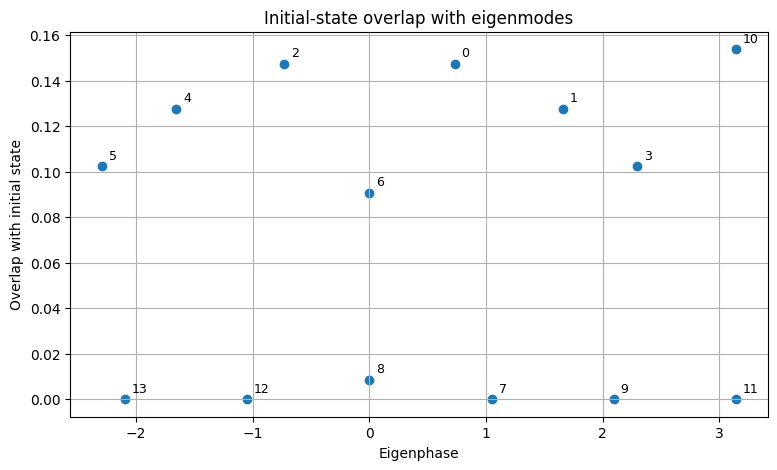

Top overlapping eigenmodes:
mode k | eigenphase | overlap | IPR
--------------------------------------
    10 |     3.1416 |  0.1538 |  0.1272
     0 |     0.7294 |  0.1475 |  0.1202
     2 |    -0.7294 |  0.1475 |  0.1202
     1 |     1.6554 |  0.1278 |  0.1034
     4 |    -1.6554 |  0.1278 |  0.1034
     3 |     2.2930 |  0.1024 |  0.0921
     5 |    -2.2930 |  0.1024 |  0.0921
     6 |    -0.0000 |  0.0907 |  0.0905
     8 |     0.0000 |  0.0086 |  0.2741
    11 |     3.1416 |  0.0001 |  0.1666
Eigenmode 13
Eigenphase: -2.0944

Top edge support:
edge index | edge | probability
-------------------------------
         2 | (2, 0) | 0.3333
        11 | (7, 2) | 0.3333
         9 | (0, 7) | 0.3333
         8 | (6, 1) | 0.0000
         7 | (5, 6) | 0.0000
         6 | (1, 5) | 0.0000
         4 | (3, 4) | 0.0000
         5 | (4, 1) | 0.0000
        10 | (7, 0) | 0.0000
         0 | (0, 1) | 0.0000
Eigenmode 10
Eigenphase: 3.1416

Top edge support:
edge index | edge | probability
--------

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

from simple_random_walk import U_grover, U_random, grover_coin, build_eulerian_walk_operator

eigvals, eigvecs = np.linalg.eig(U_grover)

def plot_eigenphases(U, title="Eigenphases"):
    eigvals = np.linalg.eigvals(U)
    phases = np.angle(eigvals)

    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(phases)), np.sort(phases))
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Phase")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return phases


phases_grover = plot_eigenphases(U_grover, "Eulerian Grover eigenphases")
phases_random = plot_eigenphases(U_random, "Random unitary eigenphases")


def print_eigenvalue_degeneracies(U, tol=1e-8):
    eigvals = np.linalg.eigvals(U)
    phases = np.sort(np.angle(eigvals))

    groups = []
    current_group = [phases[0]]

    for p in phases[1:]:
        if abs(p - current_group[-1]) < tol:
            current_group.append(p)
        else:
            groups.append(current_group)
            current_group = [p]

    groups.append(current_group)

    for g in groups:
        if len(g) > 1:
            print(f"Phase {g[0]:.6f} has degeneracy {len(g)}")

print("Grover degeneracies:")
print_eigenvalue_degeneracies(U_grover)

print("Random degeneracies:")
print_eigenvalue_degeneracies(U_random)

def eigenvector_ipr(U):
    eigvals, eigvecs = np.linalg.eig(U)

    iprs = []

    for k in range(eigvecs.shape[1]):
        phi = eigvecs[:, k]
        p = np.abs(phi) ** 2
        p = p / np.sum(p)
        iprs.append(np.sum(p ** 2))

    return eigvals, np.array(iprs)


eigvals_g, ipr_g = eigenvector_ipr(U_grover)
eigvals_r, ipr_r = eigenvector_ipr(U_random)

plt.figure(figsize=(8, 4))
plt.scatter(np.angle(eigvals_g), ipr_g, label="Eulerian Grover")
plt.scatter(np.angle(eigvals_r), ipr_r, label="Random unitary")
plt.xlabel("Eigenphase")
plt.ylabel("Eigenvector IPR")
plt.title("Eigenmode localization")
plt.legend()
plt.grid(True)
plt.show()

def plot_most_localized_eigenvector(U, edges, title="Most localized eigenvector"):
    eigvals, eigvecs = np.linalg.eig(U)

    iprs = []
    probs = []

    for k in range(eigvecs.shape[1]):
        phi = eigvecs[:, k]
        p = np.abs(phi) ** 2
        p = p / np.sum(p)
        probs.append(p)
        iprs.append(np.sum(p ** 2))

    kmax = np.argmax(iprs)

    plt.figure(figsize=(10, 4))
    plt.bar([str(e) for e in edges], probs[kmax])
    plt.xticks(rotation=45)
    plt.ylabel("Probability")
    plt.title(title + f"\nEigenphase = {np.angle(eigvals[kmax]):.3f}, IPR = {iprs[kmax]:.3f}")
    plt.tight_layout()
    plt.show()

    return eigvals[kmax], eigvecs[:, kmax], iprs[kmax]

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1),

    (0,7),
    (7,0),
    (7,2),
    (2,8),
    (8,7)
]

lam, phi, ipr = plot_most_localized_eigenvector(
    U_grover, edges, "Most localized Eulerian Grover eigenmode"
)

def eigenmode_overlaps(U, start_index):
    eigvals, eigvecs = np.linalg.eig(U)

    psi0 = np.zeros(U.shape[0], dtype=complex)
    psi0[start_index] = 1.0

    overlaps = []

    for k in range(eigvecs.shape[1]):
        phi = eigvecs[:, k]
        phi = phi / np.linalg.norm(phi)
        c = np.vdot(phi, psi0)
        overlaps.append(abs(c) ** 2)

    return eigvals, np.array(overlaps)

start_index = 0
eigvals, overlaps = eigenmode_overlaps(U_grover, start_index)

plt.figure(figsize=(8, 4))
plt.scatter(np.angle(eigvals), overlaps)
plt.xlabel("Eigenphase")
plt.ylabel("Overlap with initial state")
plt.title("Initial-state overlap with eigenmodes")
plt.grid(True)
plt.show()

def compare_spectral_properties(U1, U2, labels=("Grover", "Random")):
    eig1, ipr1 = eigenvector_ipr(U1)
    eig2, ipr2 = eigenvector_ipr(U2)

    plt.figure(figsize=(8, 4))
    plt.scatter(np.angle(eig1), ipr1, label=labels[0])
    plt.scatter(np.angle(eig2), ipr2, label=labels[1])
    plt.xlabel("Eigenphase")
    plt.ylabel("Eigenvector IPR")
    plt.title("Spectral localization comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_spectral_properties(U_grover, U_random)

def plot_labeled_eigenmode_overlaps(U, start_index):
    eigvals, eigvecs = np.linalg.eig(U)

    psi0 = np.zeros(U.shape[0], dtype=complex)
    psi0[start_index] = 1.0

    overlaps = []

    for k in range(eigvecs.shape[1]):
        phi = eigvecs[:, k]
        phi = phi / np.linalg.norm(phi)

        c = np.vdot(phi, psi0)
        overlaps.append(abs(c) ** 2)

    overlaps = np.array(overlaps)
    phases = np.angle(eigvals)

    plt.figure(figsize=(9, 5))
    plt.scatter(phases, overlaps)

    for k in range(len(eigvals)):
        plt.annotate(
            str(k),
            (phases[k], overlaps[k]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.xlabel("Eigenphase")
    plt.ylabel("Overlap with initial state")
    plt.title("Initial-state overlap with eigenmodes")
    plt.grid(True)
    plt.show()

    return eigvals, eigvecs, overlaps


eigvals, eigvecs, overlaps = plot_labeled_eigenmode_overlaps(U_grover, start_index=0)


def print_top_overlapping_modes(U, start_index, top_n=8):
    eigvals, eigvecs = np.linalg.eig(U)

    psi0 = np.zeros(U.shape[0], dtype=complex)
    psi0[start_index] = 1.0

    rows = []

    for k in range(eigvecs.shape[1]):
        phi = eigvecs[:, k]
        phi = phi / np.linalg.norm(phi)

        c = np.vdot(phi, psi0)
        overlap = abs(c) ** 2
        phase = np.angle(eigvals[k])

        p = np.abs(phi) ** 2
        p = p / np.sum(p)
        ipr = np.sum(p ** 2)

        rows.append((k, phase, overlap, ipr))

    rows = sorted(rows, key=lambda x: x[2], reverse=True)

    print("Top overlapping eigenmodes:")
    print("mode k | eigenphase | overlap | IPR")
    print("--------------------------------------")

    for k, phase, overlap, ipr in rows[:top_n]:
        print(f"{k:6d} | {phase:10.4f} | {overlap:7.4f} | {ipr:7.4f}")

    return rows


rows = print_top_overlapping_modes(U_grover, start_index=0, top_n=10)

def print_eigenmode_edge_support(U, edges, mode_index, top_n=10):
    eigvals, eigvecs = np.linalg.eig(U)

    phi = eigvecs[:, mode_index]
    phi = phi / np.linalg.norm(phi)

    probs = np.abs(phi) ** 2
    probs = probs / np.sum(probs)

    ranked = sorted(
        list(enumerate(probs)),
        key=lambda x: x[1],
        reverse=True
    )

    print(f"Eigenmode {mode_index}")
    print(f"Eigenphase: {np.angle(eigvals[mode_index]):.4f}")
    print()
    print("Top edge support:")
    print("edge index | edge | probability")
    print("-------------------------------")

    for edge_index, prob in ranked[:top_n]:
        print(f"{edge_index:10d} | {edges[edge_index]} | {prob:.4f}")

    return probs


probs = print_eigenmode_edge_support(U_grover, edges, mode_index=13)
probs = print_eigenmode_edge_support(U_grover, edges, mode_index=10)
probs = print_eigenmode_edge_support(U_grover, edges, mode_index=0)
probs = print_eigenmode_edge_support(U_grover, edges, mode_index=2)
probs = print_eigenmode_edge_support(U_grover, edges, mode_index=6)